In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/supply_chain_data.csv')

In [3]:
print(df.info())
print(df.head())
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    str    
 1   SKU                      100 non-null    str    
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    str    
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    str    
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    str    
 14  Location                 100 non-null 

In [5]:
print(df.columns)

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='str')


In [6]:
df['Total Lead Time'] = df['Lead times'] + df['Shipping times']

In [7]:
carrier_performance = df.groupby('Shipping carriers')[['Shipping times', 'Shipping costs']].mean().reset_index()

In [8]:
supplier_performance = df.groupby('Supplier name')[['Lead times', 'Defect rates']].mean().reset_index()

In [9]:
location_performance = df.groupby('Location')[['Lead times', 'Shipping times', 'Defect rates']].mean().reset_index()

In [10]:
avg_shipping_time = df['Shipping times'].mean()
avg_lead_time = df['Lead times'].mean()
avg_defect_rate = df['Defect rates'].mean()
total_revenue = df['Revenue generated'].sum()
total_costs = df['Costs'].sum()
cost_ratio = total_costs / total_revenue

In [11]:
print(f"Average Shipping Time: {avg_shipping_time:.2f} days")
print(f"Average Lead Time: {avg_lead_time:.2f} days")
print(f"Average Defect Rate: {avg_defect_rate:.2f}%")
print(f"Revenue to Cost Ratio: {cost_ratio:.2f}")

Average Shipping Time: 5.75 days
Average Lead Time: 15.96 days
Average Defect Rate: 2.28%
Revenue to Cost Ratio: 0.09


In [12]:
plt.figure(figsize=(24, 18), dpi=100)
sns.set_style("whitegrid")

<Figure size 2400x1800 with 0 Axes>

C:\Users\Testing\AppData\Local\Temp\ipykernel_17796\1582475492.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Shipping carriers', y='Shipping times', palette='viridis', ci=None)
C:\Users\Testing\AppData\Local\Temp\ipykernel_17796\1582475492.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Shipping carriers', y='Shipping times', palette='viridis', ci=None)


Text(0, 0.5, 'Days')

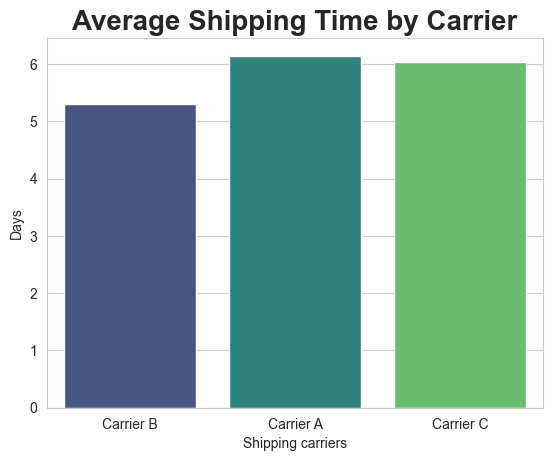

In [14]:
plt.subplot(1,1,1)
sns.barplot(data=df, x='Shipping carriers', y='Shipping times', palette='viridis', ci=None)
plt.title('Average Shipping Time by Carrier', fontsize=20, fontweight='bold')
plt.ylabel('Days')

Text(0.5, 1.0, 'Shipping Cost vs Shipping Time')

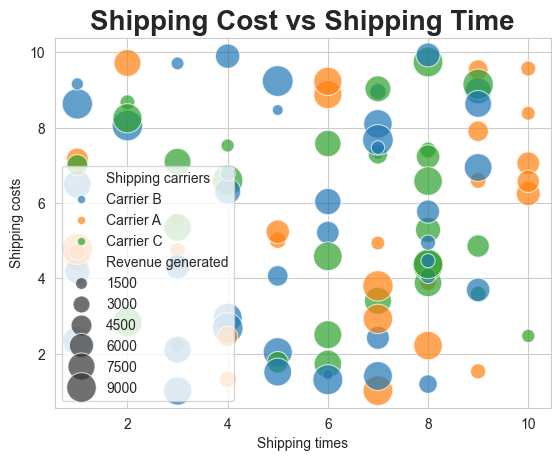

In [15]:
plt.subplot(1,1,1)
sns.scatterplot(data=df, x='Shipping times', y='Shipping costs', hue='Shipping carriers', size='Revenue generated', sizes=(50, 500), alpha=0.7)
plt.title('Shipping Cost vs Shipping Time', fontsize=20, fontweight='bold')

C:\Users\Testing\AppData\Local\Temp\ipykernel_17796\964784288.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Supplier name', y='Defect rates', palette='magma', ci=None)
C:\Users\Testing\AppData\Local\Temp\ipykernel_17796\964784288.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Supplier name', y='Defect rates', palette='magma', ci=None)


Text(0.5, 1.0, 'Average Defect Rate by Supplier')

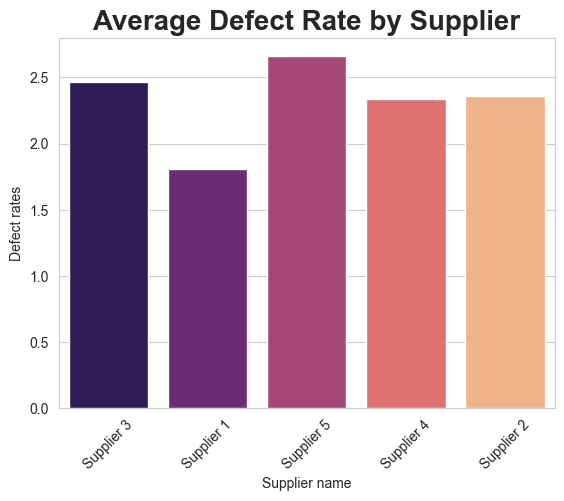

In [16]:
plt.subplot(1,1,1)
sns.barplot(data=df, x='Supplier name', y='Defect rates', palette='magma', ci=None)
plt.xticks(rotation=45)
plt.title('Average Defect Rate by Supplier', fontsize=20, fontweight='bold')

C:\Users\Testing\AppData\Local\Temp\ipykernel_17796\4188701161.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_melted, x='Location', y='Days', hue='Metric', palette='Set2', ci=None)


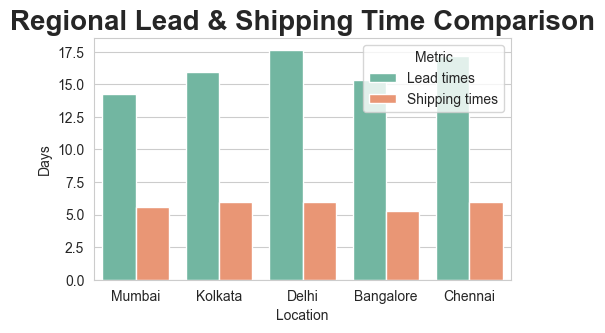

In [17]:
plt.subplot(1,1,1)
df_melted = df.melt(id_vars='Location', value_vars=['Lead times', 'Shipping times'], var_name='Metric', value_name='Days')
sns.barplot(data=df_melted, x='Location', y='Days', hue='Metric', palette='Set2', ci=None)
plt.title('Regional Lead & Shipping Time Comparison', fontsize=20, fontweight='bold')

plt.tight_layout(pad=6.0)
plt.savefig('supply_chain_analysis_report.png')
plt.show()

In [18]:
high_risk_suppliers = df[(df['Defect rates'] > avg_defect_rate) & (df['Lead times'] > avg_lead_time)]
print("\nHigh Risk Supplier Segments (Count):", len(high_risk_suppliers))


High Risk Supplier Segments (Count): 27
